In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.metrics import confusion_matrix, classification_report
import string
import re

In [25]:
df = pd.read_csv('train_clean.csv')
df.head()

,Survived,PassengerClass,Sex,Age,SibSp,ParentsChildrenAboard,Fare,Embarked
0,0,3,1,22.0,1,0,7.2500,0
1,1,1,0,38.0,1,0,71.2833,1
2,1,3,0,26.0,0,0,7.9250,0
3,1,1,0,35.0,1,0,53.1000,0
4,0,3,1,35.0,0,0,8.0500,0


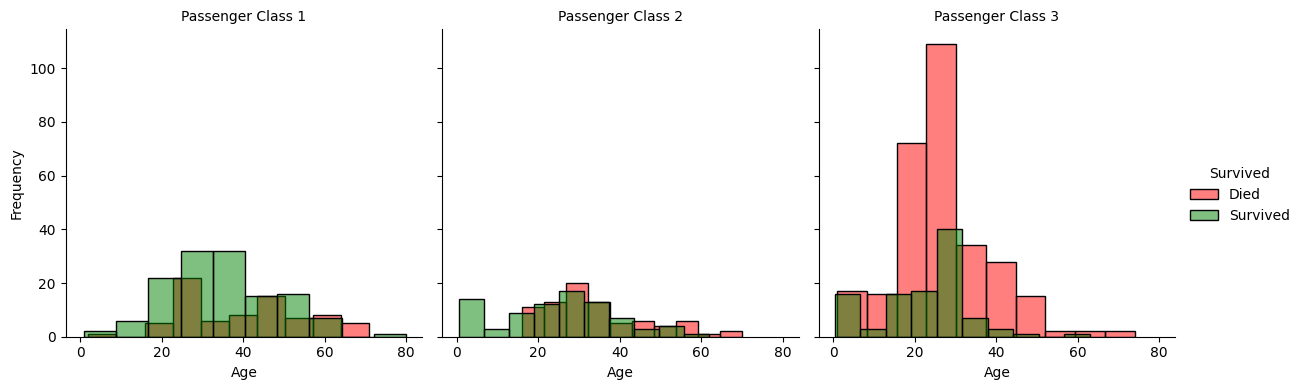

In [26]:
g = sns.FacetGrid(df, col='PassengerClass', hue='Survived', 
                  palette={0: 'red', 1: 'green'}, height=4)
g.map(sns.histplot, 'Age', bins=10, alpha=0.5)
g.add_legend(title='Survived', labels=['Died', 'Survived'])
g.set_axis_labels('Age', 'Frequency')
g.set_titles('Passenger Class {col_name}')
plt.show()

In [27]:
#create a feature engineering to understand the size of the family by extracting sibsp and parentschildrenabord

df['Family_Size'] = df['SibSp'] + df['ParentsChildrenAboard'] + 1
print(df['Family_Size'].value_counts())

Family_Size
1     437
2     154
3     101
4      28
6      22
5      13
7      12
8       6
11      2
Name: count, dtype: int64


In [28]:
#separate the features and target variable
X = df.drop(columns=['Survived'])
y = df['Survived']

In [29]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training size:", x_train.shape)
print("Testing size:", x_test.shape)

Training size: (620, 8)
Testing size: (155, 8)


In [30]:
# Train a logistic regression model
logistic_model = LogisticRegression(max_iter=1000)
logistic_model.fit(x_train, y_train)

logistic_predictions = logistic_model.predict(x_test)

In [31]:
# Train a random forest model
random_forest_model = RandomForestClassifier(n_estimators=100, random_state=42)
random_forest_model.fit(x_train, y_train)

random_forest_model_predictions = random_forest_model.predict(x_test)

In [32]:
#comparing the accuracy of the two models
print("Logistic Regression Accuracy:", accuracy_score(y_test, logistic_predictions))
print("Random Forest Accuracy:", accuracy_score(y_test, random_forest_model_predictions))

Logistic Regression Accuracy: 0.7677419354838709
Random Forest Accuracy: 0.7612903225806451


In [33]:
print("==== Logistic Regression Classification Report ====")
print(confusion_matrix(y_test, logistic_predictions))
print(classification_report(y_test, logistic_predictions))

print("==== Random Forest Classification Report ====")
print(confusion_matrix(y_test, random_forest_model_predictions))
print(classification_report(y_test, random_forest_model_predictions))

==== Logistic Regression Classification Report ====
[[76 19]
 [17 43]]
              precision    recall  f1-score   support

           0       0.82      0.80      0.81        95
           1       0.69      0.72      0.70        60

    accuracy                           0.77       155
   macro avg       0.76      0.76      0.76       155
weighted avg       0.77      0.77      0.77       155

==== Random Forest Classification Report ====
[[77 18]
 [19 41]]
              precision    recall  f1-score   support

           0       0.80      0.81      0.81        95
           1       0.69      0.68      0.69        60

    accuracy                           0.76       155
   macro avg       0.75      0.75      0.75       155
weighted avg       0.76      0.76      0.76       155



In [ ]:
# ===== MODEL EVALUATION REPORT =====

# CONFUSION MATRIX BREAKDOWN
# Logistic Regression:
# [[76  19]   → 76 correctly predicted DIED, 19 wrongly predicted as SURVIVED
#  [17  43]]  → 17 wrongly predicted as DIED, 43 correctly predicted SURVIVED

# Random Forest:
# [[77  18]   → 77 correctly predicted DIED, 18 wrongly predicted as SURVIVED
#  [19  41]]  → 19 wrongly predicted as DIED, 41 correctly predicted SURVIVED

# PRECISION — when model says "survived", how often is it right?
# LR: 0.69 | RF: 0.69 → both correct 69% of the time when predicting survival

# RECALL — out of all actual survivors, how many did model catch?
# LR: 0.72 | RF: 0.68 → LR caught more actual survivors than RF

# F1-SCORE — balance between precision and recall (higher is better)
# LR: 0.70 | RF: 0.69 → LR slightly better at identifying survivors

# OVERALL ACCURACY
# LR: 77% | RF: 76% → Logistic Regression wins by a small margin

# CONCLUSION
# Logistic Regression performs slightly better on this dataset
# Both models are better at predicting deaths (class 0) than survivals (class 1)
# This is because there are more deaths (95) than survivals (60) in test set
# This imbalance causes the model to be biased towards predicting death

In [34]:
#improving random forest model by tuning hyperparameters
randomF_model2 = RandomForestClassifier(
    n_estimators=200, 
    max_depth=10, 
    random_state=42
)

randomF_model2.fit(x_train, y_train)
randomF_model2_predictions = randomF_model2.predict(x_test)
print("Random Forest Model 2 Accuracy:", accuracy_score(y_test, randomF_model2_predictions))

Random Forest Model 2 Accuracy: 0.7806451612903226


In [ ]:
#added feature importance plot to understand which features are most influential in the random forest model

importance = pd.Series(randomF_model2.feature_importances_, index=X.columns)
importance.sort_values().plot(kind='barh', color='steelblue')
plt.title('Feature Importance')
plt.xlabel('Importance Score')
plt.show()